# Homework 3.1 — Event-study regressions

## tl;dr

| Quiz question | Answer | Evidence |
|---|---|---|
| Q1: Strongest discontinuity in the value at time 50 | **A — value3** | Level-only jump = **1.767254**, t = **4.356868**, p = **0.00003279** |
| Q2: Strongest discontinuity in the derivative at time 50 | **C — value1** | Slope change = **0.105325**, t = **7.951259**, p = **3.602 × 10⁻¹²** |

Both the largest absolute coefficient and the strongest statistical evidence
give these rankings. Questions 3–5 are in `homework_3.2_differences_in_differences.ipynb`.

## Context & Methods

Source: `homework_3.1.csv` in the project folder. Each of its 100 rows
contains a time and three outcome series. The event occurs at time 50.
Use all observations, center time as $x_t = time_t - 50$, and define
$Post_t = 1[time_t \geq 50]$.

For Q1, fit a common slope before and after the event:

$$Y_t = \alpha + \beta x_t + \delta Post_t + \varepsilon_t.$$

Here $\delta$ is the discontinuity in the **level**. For Q2, allow both a jump
and a change in slope:

$$Y_t = \alpha + \beta x_t + \delta Post_t
       + \gamma(x_t Post_t) + \varepsilon_t.$$

The slope before the event is $\beta$, the slope after is $\beta+\gamma$,
and $\gamma$ is the discontinuity in the **first derivative**. Centering time
makes $\delta$ the level jump at the event even when the slopes differ.

### Key Assumptions

- Linear trends are appropriate within each segment. No observations are removed or imputed.
- Conventional OLS standard errors assume independent, constant-variance errors.
  Serial correlation would require a different standard-error calculation.
- Compare two-sided tests of each relevant coefficient against zero.
  A larger absolute t statistic and smaller p-value mean stronger evidence.
- An event-time break by itself does not establish that the event caused the change.

If packages are missing, run `%pip install numpy pandas scipy matplotlib scikit-learn`.
Keep the source CSV in the project folder above `Homework Code`.

## Data

### 1. Set up the analysis

In [1]:
from pathlib import Path
import hashlib
import importlib.metadata
import platform

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.linear_model import LinearRegression
from IPython.display import display, Markdown

pd.set_option('display.precision', 6)
plt.rcParams.update({
    'figure.figsize': (9, 4.8), 'figure.dpi': 110,
    'font.size': 11, 'axes.titlesize': 13,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.color': '#E5E7EB', 'axes.axisbelow': True,
    'text.color': '#1F2937', 'axes.labelcolor': '#1F2937',
    'savefig.bbox': 'tight',
})
BLUE, GOLD, DARK = '#2563EB', '#B7791F', '#374151'

def locate_csv(filename):
    # Works from the project folder or any folder beneath it, including HW3.
    for folder in (Path.cwd(), *Path.cwd().parents):
        candidate = folder / filename
        if candidate.is_file():
            return candidate.resolve()
    raise FileNotFoundError(
        f'Cannot find {filename}. Run from the project folder or a subfolder.'
    )

def show_table(frame, formats=None):
    display(frame.style.hide(axis='index').format(formats or {}, na_rep='—'))

### 2. Load and check the source

In [2]:
DATA_PATH = locate_csv('homework_3.1.csv')
EVENT_TIME = 50
SERIES = ['value1', 'value2', 'value3']
data = pd.read_csv(DATA_PATH)
required = ['time', *SERIES]
if not set(required).issubset(data.columns):
    raise ValueError(f'Required columns: {required}')
if not all(pd.api.types.is_numeric_dtype(data[c]) for c in required):
    raise TypeError('The time and outcome columns must be numeric.')
if not np.isfinite(data[required].to_numpy()).all():
    raise ValueError('Source contains missing or infinite values.')
if data['time'].duplicated().any():
    raise ValueError('Expected one row per time value.')
data = data.sort_values('time').reset_index(drop=True)
data['centered_time'] = data['time'] - EVENT_TIME
data['post'] = (data['time'] >= EVENT_TIME).astype(int)
data['slope_change'] = data['centered_time'] * data['post']
assert set(data['post']) == {0, 1}

show_table(pd.DataFrame({
    'Source': [DATA_PATH.name], 'Rows': [len(data)],
    'First time': [data['time'].min()], 'Last time': [data['time'].max()],
    'Before': [(data['post'] == 0).sum()], 'After': [data['post'].sum()],
    'Missing values': [int(data[required].isna().sum().sum())],
}))
print('SHA-256:', hashlib.sha256(DATA_PATH.read_bytes()).hexdigest())
display(data[required].head())

Source,Rows,First time,Last time,Before,After,Missing values
homework_3.1.csv,100,0,99,50,50,0


SHA-256: 458ca6aefd8268173ad081e8325251aebbe235519004715abe61336858e8427b


,time,value1,value2,value3
0,0,1.764052,1.883151,-0.369182
1,1,0.420157,-1.327759,-0.219379
2,2,1.018738,-1.230485,1.139660
3,3,2.300893,1.029397,0.715264
4,4,1.947558,-1.093123,0.720132


## Results

### 3. Compute OLS estimates and regression standard errors

The helper below uses NumPy for least squares and SciPy for Student-t tests.
It implements the usual OLS formulas explicitly:
$\widehat{\sigma}^2=\sum_t\widehat{\varepsilon}_t^2/(n-k)$ and
$\widehat{\operatorname{Var}}(\widehat{\theta})=
\widehat{\sigma}^2(X^TX)^{-1}$. Confidence intervals are 95% intervals.

In [3]:
def fit_ols(outcome, design):
    """OLS with an explicit intercept column and conventional regression SEs."""
    X = design.to_numpy(dtype=float)
    y = np.asarray(outcome, dtype=float)
    n, k = X.shape
    if not np.isfinite(X).all() or not np.isfinite(y).all():
        raise ValueError('The regression contains missing or infinite values.')
    if np.linalg.matrix_rank(X) != k or n <= k:
        raise ValueError('The design must have full rank and positive residual df.')

    beta = np.linalg.lstsq(X, y, rcond=None)[0]
    fitted = X @ beta
    residuals = y - fitted
    residual_df = n - k
    residual_variance = (residuals @ residuals) / residual_df
    covariance = residual_variance * np.linalg.inv(X.T @ X)
    standard_errors = np.sqrt(np.diag(covariance))
    t_values = beta / standard_errors
    critical_t = stats.t.ppf(0.975, residual_df)
    coefficients = pd.DataFrame({
        'Estimate': beta,
        'SE': standard_errors,
        't': t_values,
        'p-value': 2 * stats.t.sf(np.abs(t_values), residual_df),
        '95% CI lower': beta - critical_t * standard_errors,
        '95% CI upper': beta + critical_t * standard_errors,
    }, index=design.columns)
    return {
        'coefficients': coefficients, 'fitted': fitted,
        'residual_variance': residual_variance, 'residual_df': residual_df,
    }

COEF_FORMAT = {column: '{:.6f}' for column in
               ['Estimate', 'SE', 't', '95% CI lower', '95% CI upper']}
COEF_FORMAT['p-value'] = '{:.3e}'

### 4. Q1 — Test a level jump with an unchanged slope

In [4]:
level_design = pd.DataFrame({
    'Intercept': 1.0, 'Time trend': data['centered_time'],
    'Level jump': data['post'],
})
level_models = {name: fit_ols(data[name], level_design) for name in SERIES}
level_results = pd.DataFrame([
    {'Series': name, **model['coefficients'].loc['Level jump'].to_dict()}
    for name, model in level_models.items()
])
show_table(level_results, COEF_FORMAT)
q1_series = level_results.loc[level_results['p-value'].idxmin(), 'Series']
assert q1_series == level_results.loc[level_results['Estimate'].abs().idxmax(), 'Series']
display(Markdown(f'**Q1: Option A — {q1_series}.** It has the largest level jump '
                 'and the smallest p-value in the common-slope model.'))

Series,Estimate,SE,t,p-value,95% CI lower,95% CI upper
value1,0.850813,0.489889,1.736745,8.561e-02,-0.121482,1.823108
value2,0.682746,0.427019,1.598864,1.131e-01,-0.164770,1.530261
value3,1.767254,0.405625,4.356868,3.279e-05,0.962201,2.572307


**Q1: Option A — value3.** It has the largest level jump and the smallest p-value in the common-slope model.

### 5. Q2 — Test the change in slope while allowing a level jump

In [5]:
piecewise_design = level_design.assign(**{'Slope change': data['slope_change']})
piecewise_models = {name: fit_ols(data[name], piecewise_design) for name in SERIES}
slope_results = pd.DataFrame([
    {'Series': name, **model['coefficients'].loc['Slope change'].to_dict()}
    for name, model in piecewise_models.items()
])
show_table(slope_results, COEF_FORMAT)
q2_series = slope_results.loc[slope_results['p-value'].idxmin(), 'Series']
assert q2_series == slope_results.loc[slope_results['Estimate'].abs().idxmax(), 'Series']
display(Markdown(f'**Q2: Option C — {q2_series}.** It has the largest slope change '
                 'and the smallest p-value for that change.'))

Series,Estimate,SE,t,p-value,95% CI lower,95% CI upper
value1,0.105325,0.013246,7.951259,3.602e-12,0.079031,0.131618
value2,0.036921,0.014385,2.566732,1.181e-02,0.008368,0.065475
value3,0.050695,0.013143,3.857133,2.077e-04,0.024606,0.076784


**Q2: Option C — value1.** It has the largest slope change and the smallest p-value for that change.

### 6. Compare the fitted trends

Series,Slope before,Slope after,Slope change,Level jump at 50
value1,-0.008809,0.096516,0.105325,0.903475
value2,0.010304,0.047225,0.036921,0.701206
value3,0.010928,0.061623,0.050695,1.792602


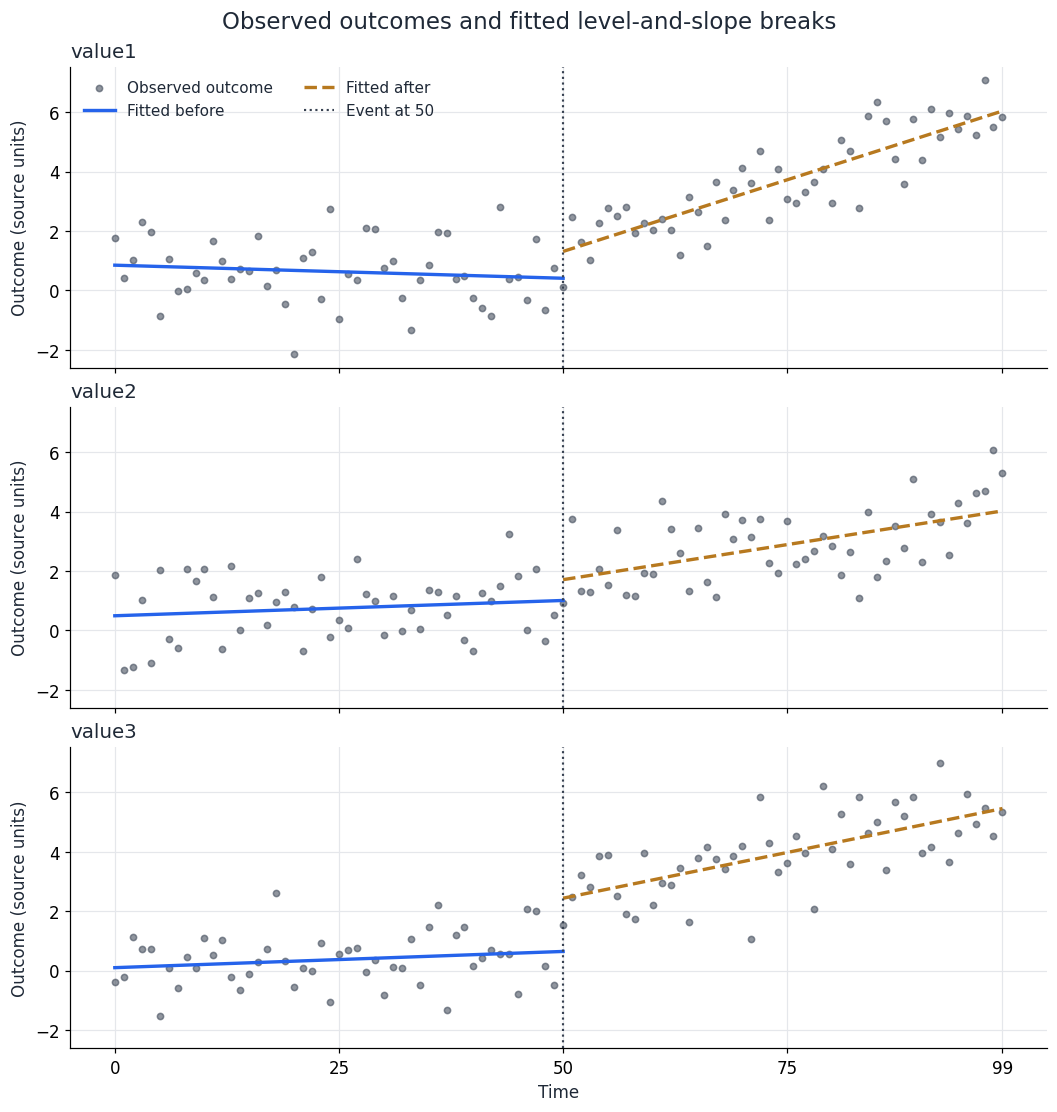

In [6]:
trend_details = []
for name, model in piecewise_models.items():
    coefficients = model['coefficients']['Estimate']
    trend_details.append({
        'Series': name, 'Slope before': coefficients['Time trend'],
        'Slope after': coefficients['Time trend'] + coefficients['Slope change'],
        'Slope change': coefficients['Slope change'],
        'Level jump at 50': coefficients['Level jump'],
    })
show_table(pd.DataFrame(trend_details), {
    column: '{:.6f}' for column in trend_details[0] if column != 'Series'
})

fig, axes = plt.subplots(3, 1, figsize=(9.5, 10), sharex=True, sharey=True,
                         constrained_layout=True)
for ax, name in zip(axes, SERIES):
    coefficients = piecewise_models[name]['coefficients']['Estimate']
    ax.scatter(data['time'], data[name], s=17, color=DARK, alpha=0.55,
               label='Observed outcome')
    for post_value, color, line_style, label in [
        (0, BLUE, '-', 'Fitted before'), (1, GOLD, '--', 'Fitted after')
    ]:
        times = np.linspace(data['time'].min() if post_value == 0 else EVENT_TIME,
                            EVENT_TIME if post_value == 0 else data['time'].max(), 100)
        centered = times - EVENT_TIME
        fitted = (coefficients['Intercept'] + coefficients['Time trend'] * centered
                  + coefficients['Level jump'] * post_value
                  + coefficients['Slope change'] * centered * post_value)
        ax.plot(times, fitted, color=color, linestyle=line_style, linewidth=2.2, label=label)
    ax.axvline(EVENT_TIME, color=DARK, linestyle=':', linewidth=1.4, label='Event at 50')
    ax.set_title(name, loc='left')
    ax.set_ylabel('Outcome (source units)')
    ax.set_xticks([0, 25, 50, 75, 99])
axes[0].legend(frameon=False, ncol=2, fontsize=10)
axes[-1].set_xlabel('Time')
fig.suptitle('Observed outcomes and fitted level-and-slope breaks', fontsize=15)
plt.show()

The fitted lines allow a separate level and slope after the event. `value3` has the largest level jump in this model too. `value1` has the strongest increase in slope.

### 7. Compare estimates and their uncertainty

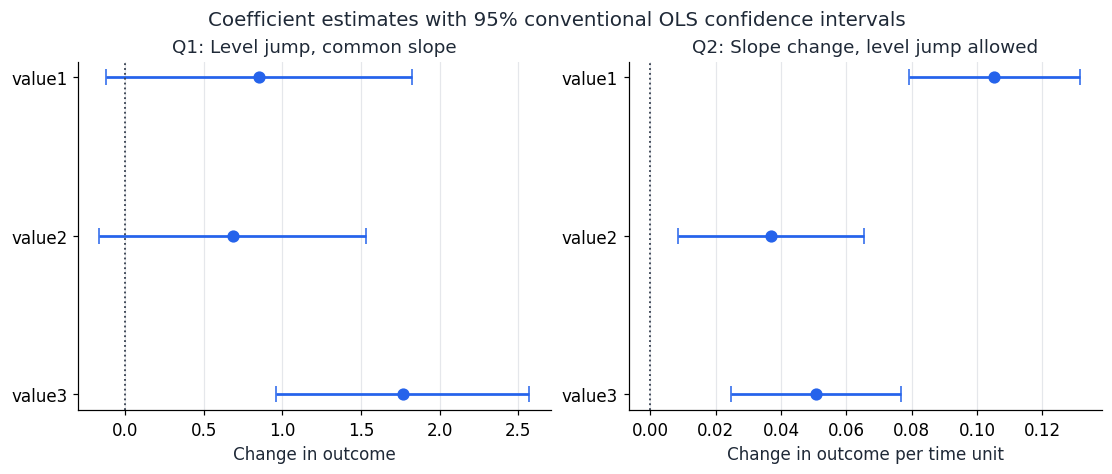

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4.2), constrained_layout=True)
for ax, results, title, units in [
    (axes[0], level_results, 'Q1: Level jump, common slope', 'Change in outcome'),
    (axes[1], slope_results, 'Q2: Slope change, level jump allowed', 'Change in outcome per time unit'),
]:
    estimate = results['Estimate'].to_numpy()
    errors = np.vstack([estimate - results['95% CI lower'],
                        results['95% CI upper'] - estimate])
    ax.errorbar(estimate, np.arange(3), xerr=errors, fmt='o', color=BLUE,
                capsize=5, markersize=7, linewidth=1.8)
    ax.axvline(0, color=DARK, linestyle=':', linewidth=1.2)
    ax.set_yticks(np.arange(3), results['Series'])
    ax.invert_yaxis()
    ax.set_title(title, fontsize=12)
    ax.set_xlabel(units)
    ax.grid(axis='y', visible=False)
fig.suptitle('Coefficient estimates with 95% conventional OLS confidence intervals', fontsize=13)
plt.show()

In the common-slope model, only the `value3` level-jump interval excludes zero at the 5% level. All three slope-change intervals exclude zero, but `value1` has the largest estimate and strongest statistical evidence.

### 8. Verify the estimates and event-boundary convention

In [8]:
# Check OLS coefficients against an independent regression implementation.
for name in SERIES:
    check = LinearRegression(fit_intercept=False).fit(piecewise_design, data[name])
    np.testing.assert_allclose(check.coef_,
        piecewise_models[name]['coefficients']['Estimate'], atol=1e-10)

    # The interaction coefficient must equal post slope minus pre slope.
    before = data.loc[data['post'] == 0]
    after = data.loc[data['post'] == 1]
    before_slope = stats.linregress(before['time'], before[name]).slope
    after_slope = stats.linregress(after['time'], after[name]).slope
    np.testing.assert_allclose(after_slope - before_slope,
        piecewise_models[name]['coefficients'].loc['Slope change', 'Estimate'], atol=1e-10)

# Reclassify time=50 as before: the numerical estimates shift, but the answers do not.
sensitivity = []
for label, post in [('time >= 50', data['post']),
                    ('time > 50', (data['time'] > EVENT_TIME).astype(int))]:
    design = level_design.copy()
    design['Level jump'] = post
    full_design = design.assign(**{'Slope change': data['centered_time'] * post})
    level_p = {name: fit_ols(data[name], design)['coefficients'].loc['Level jump', 'p-value']
               for name in SERIES}
    slope_p = {name: fit_ols(data[name], full_design)['coefficients'].loc['Slope change', 'p-value']
               for name in SERIES}
    sensitivity.append({'Post definition': label, 'Q1': min(level_p, key=level_p.get),
                        'Q2': min(slope_p, key=slope_p.get)})
show_table(pd.DataFrame(sensitivity))
assert all(row['Q1'] == 'value3' and row['Q2'] == 'value1' for row in sensitivity)
print('Checks passed: regression coefficients, separate segment slopes, and boundary rankings.')

Post definition,Q1,Q2
time >= 50,value3,value1
time > 50,value3,value1


Checks passed: regression coefficients, separate segment slopes, and boundary rankings.


## Takeaways

Select **Q1: A — value3** and **Q2: C — value1**. A level jump changes the fitted outcome at the event; a slope change alters its rate of change afterward.

### Reproducibility

In [9]:
print('Python:', platform.python_version())
for package in ['numpy', 'pandas', 'scipy', 'matplotlib', 'scikit-learn']:
    print(f'{package}: {importlib.metadata.version(package)}')

Python: 3.13.5
numpy: 2.4.1
pandas: 3.0.0
scipy: 1.17.0
matplotlib: 3.10.8
scikit-learn: 1.8.0
